In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Leer los ficheros

In [3]:
def load_sensor_file(filefile):
    df = pd.read_csv(filefile, comment="#", sep="\s+", names=["time", "voltage"])
    df["voltage_V"] = df["voltage"] / 1000  # convertir a voltios
    return df

In [4]:
files = {
    10: "S_10.TXT",
    20: "S_20.TXT",
    30: "S_30.TXT",
    40: "S_40.TXT",
    50: "S_50.TXT",
}

data = {}

for dist, file in files.items():
    data[dist] = load_sensor_file(file)

# Análisis Exploratorio de Datos

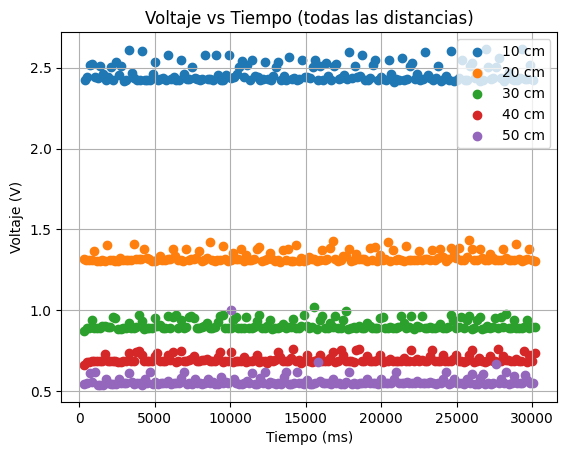

In [8]:
plt.figure()

for dist, df in data.items():
    plt.scatter(df["time"], df["voltage_V"], label=f"{dist} cm")

plt.xlabel("Tiempo (ms)")
plt.ylabel("Voltaje (V)")
plt.title("Voltaje vs Tiempo (todas las distancias)")
plt.legend()
plt.grid()

plt.show()

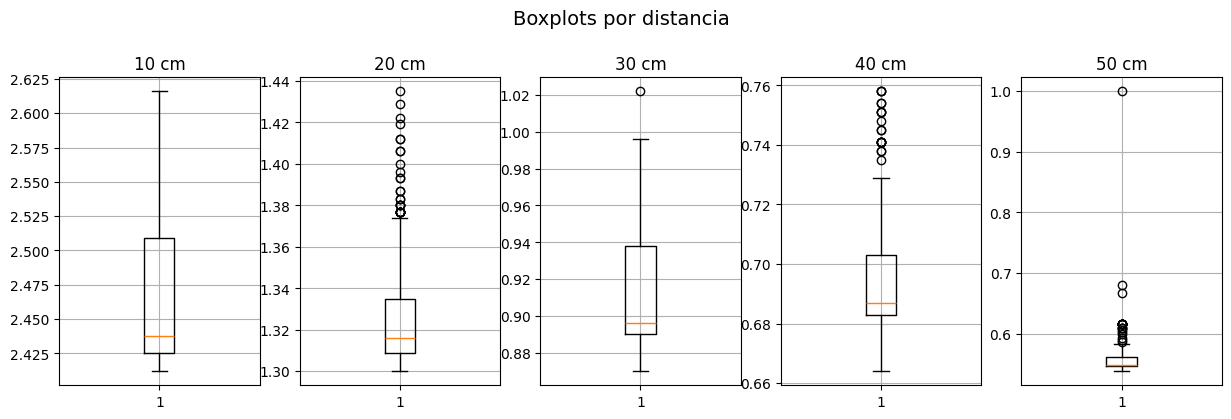

In [12]:
fig, axes = plt.subplots(1, len(data), figsize=(15, 4))

for ax, (dist, df) in zip(axes, data.items()):
    ax.boxplot(df["voltage_V"])
    ax.set_title(f"{dist} cm")
    ax.grid()

plt.suptitle("Boxplots por distancia", fontsize=14, y=1.05)
plt.show()

## Eliminación de Oulier claro para 50 cm

In [13]:
df_50 = data[50]
df_50_clean = df_50[df_50["voltage_V"] < 0.8]
data[50] = df_50_clean

## Tabla final

In [14]:
results = []

for dist, df in data.items():
    results.append({
        "Distancia (cm)": dist,
        "Voltaje medio (V)": df["voltage_V"].mean(),
        "Desviación típica (V)": df["voltage_V"].std(),
        "N muestras": len(df)
    })

clean_df = pd.DataFrame(results)
clean_df = clean_df.sort_values("Distancia (cm)").reset_index(drop=True)

clean_df

,Distancia (cm),Voltaje medio (V),Desviación típica (V),N muestras
0,10,2.466000,0.053948,172
1,20,1.329243,0.032249,173
2,30,0.910908,0.030214,173
3,40,0.696393,0.022183,173
4,50,0.558971,0.024348,171


# Ajuste a Polinomio de Grado n

In [55]:
def polynomial_fit(df, degree):
    x = df["Voltaje medio (V)"].values
    y = df["Distancia (cm)"].values

    coeffs = np.polyfit(x, y, degree)
    poly = np.poly1d(coeffs)

    pred = poly(x)
    mse = np.mean((pred - y) ** 2)

    return poly, pred, coeffs, mse

In [56]:
def plot_fit(df, degree):
    volt = df["Voltaje medio (V)"].values
    dist = df["Distancia (cm)"].values

    v_samples = np.linspace(volt.min(), volt.max(), 200)

    poly, _, coeffs, mse = polynomial_fit(df, degree)

    plt.figure()

    plt.scatter(dist, volt, label="Datos")
    dist_fit = poly(v_samples)
    plt.plot(dist_fit, v_samples, color="orange", label=f"Polinomio grado {degree}\nMSE={mse:.4f}")

    plt.xlabel("Distancia (cm)")
    plt.ylabel("Voltaje medio (V)")
    plt.title(f"Ajuste polinómico grado {degree}")

    plt.legend()
    plt.grid()
    plt.show()

    print(f"Coeficientes del polinomio grado {degree}: {coeffs}")

## Polinomio de Grado 1

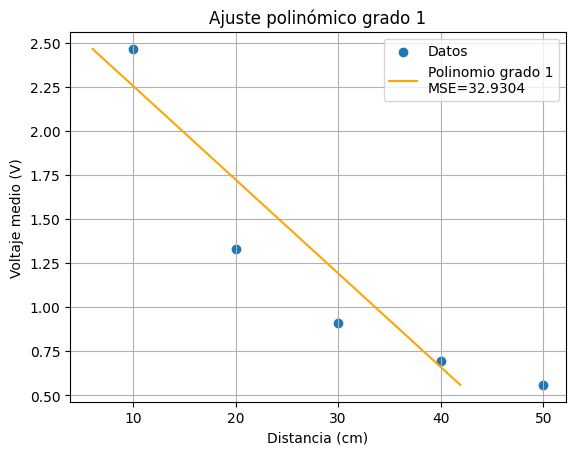

Coeficientes del polinomio grado 1: [-18.78491361  52.39730552]


In [57]:
plot_fit(clean_df, degree=1)

## Polinomio de Grado 2

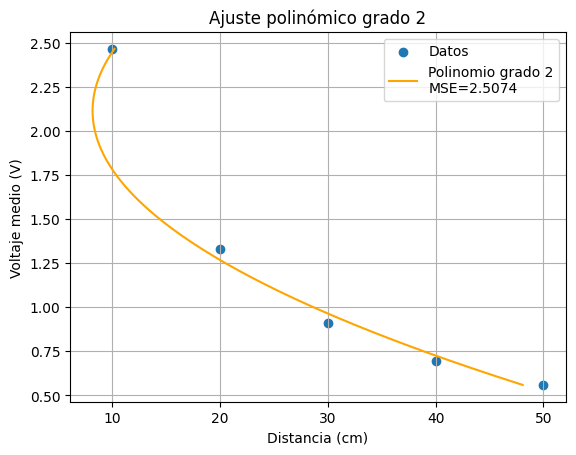

Coeficientes del polinomio grado 2: [ 16.48007256 -69.71359098  81.88929328]


In [58]:
plot_fit(clean_df, degree=2)

## Polinomio de Grado 3

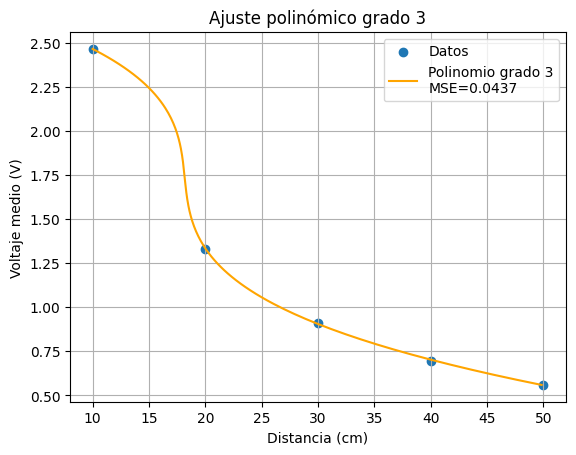

Coeficientes del polinomio grado 3: [ -18.19287148   94.85249158 -166.41894339  116.39700349]


In [59]:
plot_fit(clean_df, degree=3)

## Polinomio de Grado 4

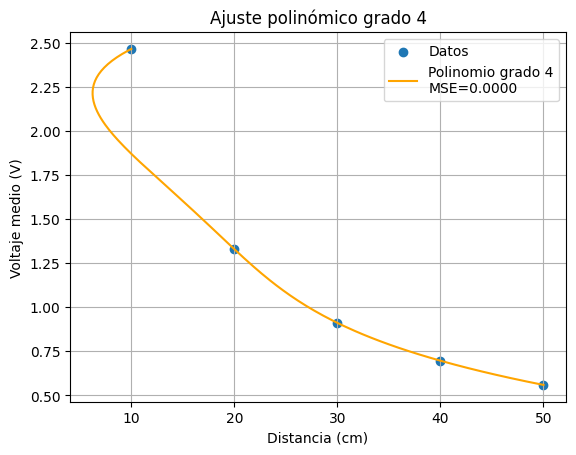

Coeficientes del polinomio grado 4: [  18.39745117 -114.18428892  263.52651144 -286.50701873  145.95682645]


In [60]:
plot_fit(clean_df, degree=4)

# Estimar Linealidad

In [ ]:
poly_lin, pred_dist, _ , _= polynomial_fit(clean_df, 1)

d_real = clean_df["Distancia (cm)"].values

error_abs = np.abs(d_real - pred_dist)

Ea_max = np.max(error_abs)

d_min = np.min(d_real)
d_max = np.max(d_real)
range = d_max - d_min

Ers = (Ea_max / range) * 100

print(f"Error absoluto máximo: {Ea_max:.4f} cm")
print(f"Linealidad (Ers): {Ers:.4f} %")

Error absoluto máximo: 8.1029 cm
Linealidad (Ers): 20.2573 %
